# 3D Coordinate Construction & ICP Slice Alignment

Load raw 10X Visium data, perform ICP alignment via STitch3D, construct 3D coordinates, and export preprocessed .h5ad files for AINR model training.

## 0. Imports

In [1]:
import os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
from sklearn.metrics import pairwise_distances

# The core: STitch3D package (same as 对齐脚本.py)
import STitch3D

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'

# ========== Parameters ==========
SLICE_IDS = [151673, 151674, 151675, 151676]
N_HVG = 3000
OUTPUT_DIR = 'demo_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

print('Slices:', SLICE_IDS)
print('STitch3D imported')

F:\env-ana\stitch3d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Slices: [151673, 151674, 151675, 151676]
STitch3D imported


## 1. ICP Alignment Functions

In [2]:
# Data path: same as 对齐脚本.py
DATA_BASE = '../../../../Code/1/STitch3D-main/STitch3D-main/data/spatialLIBD'

raw_list = []

for i, sid in enumerate(SLICE_IDS):
    data_dir = '%s/%d' % (DATA_BASE, sid)
    a = sc.read_visium(data_dir, count_file='filtered_feature_bc_matrix.h5')
    a.var_names_make_unique()
    a.obs_names = ['%s-slice%d' % (n.split('_')[0], i) for n in a.obs_names]
    raw_list.append(a)
    print('  [%d] Slice %d: %d spots x %d genes' % (i, sid, a.shape[0], a.shape[1]))

total_spots = sum(a.shape[0] for a in raw_list)
print('\nTotal: %d spots across %d slices' % (total_spots, len(raw_list)))

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Variable names are not unique. To make them unique, call `.var_names_make_unique`.


  [0] Slice 151673: 3639 spots x 33538 genes


Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Variable names are not unique. To make them unique, call `.var_names_make_unique`.


...

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


  [2] Slice 151675: 3592 spots x 33538 genes


Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Variable names are not unique. To make them unique, call `.var_names_make_unique`.


  [3] Slice 151676: 3460 spots x 33538 genes

Total: 14364 spots across 4 slices


## 2. Load Data

sc.read_visium() loads counts and spatial coordinates from 10X Visium format.

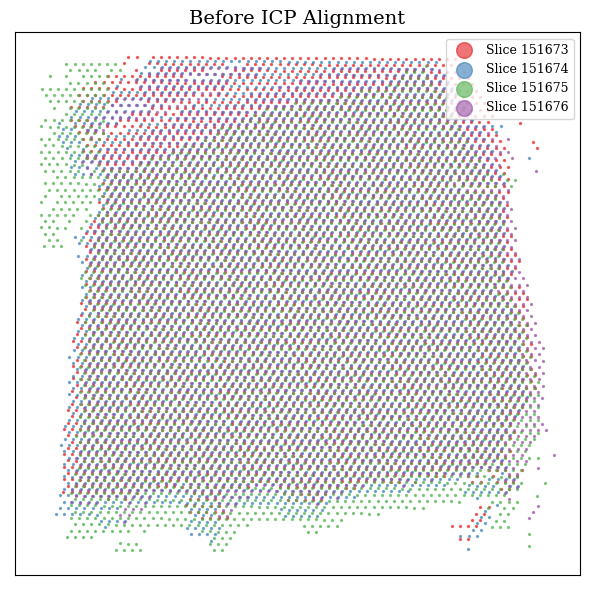

Running STitch3D.utils.align_spots() ...
Using the Iterative Closest Point algorithm for alignemnt.
Detecting edges...


Aligning edges...
Alignment complete.



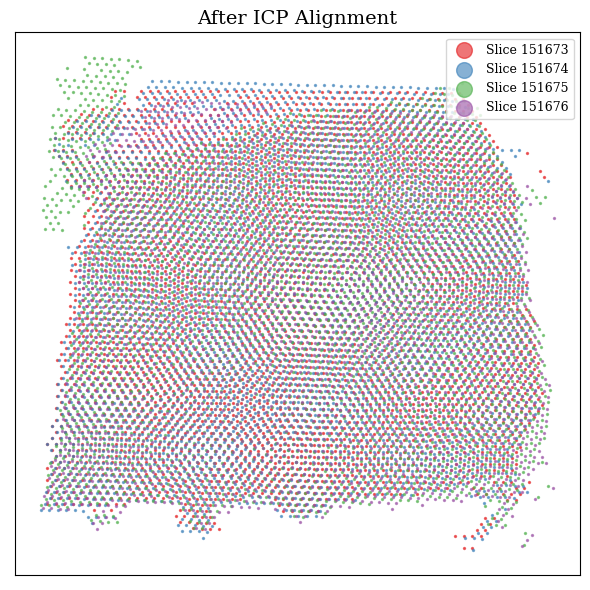

In [3]:
# ---- Before alignment ----
fig, ax = plt.subplots(figsize=(6, 6))
for i, a in enumerate(raw_list):
    xy = a.obsm['spatial']
    ax.scatter(xy[:, 0], xy[:, 1], c=COLORS[i], s=2, alpha=0.6,
               label='Slice %d' % SLICE_IDS[i])
ax.set_title('Before ICP Alignment', fontsize=14)
ax.invert_yaxis(); ax.legend(markerscale=8, fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# ---- STitch3D alignment ----
print('Running STitch3D.utils.align_spots() ...')
aligned_list = STitch3D.utils.align_spots(raw_list, method='icp', data_type='Visium', plot=False)
print('Alignment complete.\n')

# ---- After alignment ----
fig, ax = plt.subplots(figsize=(6, 6))
for i, a in enumerate(aligned_list):
    xy = a.obsm['spatial_aligned']
    ax.scatter(xy[:, 0], xy[:, 1], c=COLORS[i], s=2, alpha=0.6,
               label='Slice %d' % SLICE_IDS[i])
ax.set_title('After ICP Alignment', fontsize=14)
ax.invert_yaxis(); ax.legend(markerscale=8, fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. ICP Alignment

In [4]:
# Compute base spot distance from reference slice
loc_ref = aligned_list[0].obsm['spatial_aligned']
min_dist = np.sort(np.unique(pairwise_distances(loc_ref)), axis=None)[1]
c2c_dist = 100.0
slice_dist_micron = [10.0] * (len(SLICE_IDS) - 1)

print('Base spot distance: %.2f' % min_dist)
print('Z-scale factor: %.2f / %.1f = %.4f' % (min_dist, c2c_dist, min_dist/c2c_dist))

# Build z for each slice
all_xy, all_z = [], []
cum_z = 0.0
for i, a in enumerate(aligned_list):
    xy = a.obsm['spatial_aligned']
    all_xy.append(xy)
    z_arr = np.full(xy.shape[0], cum_z * (min_dist / c2c_dist))
    all_z.append(z_arr)
    print('  Slice %d: z = %.4f' % (SLICE_IDS[i], z_arr[0]))
    cum_z += slice_dist_micron[i] if i < len(slice_dist_micron) else 0

coords_3d = np.column_stack([np.vstack(all_xy), np.concatenate(all_z)])
print('\n3D_coor shape:', coords_3d.shape)
print('X: [%.1f, %.1f]  Y: [%.1f, %.1f]  Z: [%.4f, %.4f]' % (
    coords_3d[:,0].min(), coords_3d[:,0].max(),
    coords_3d[:,1].min(), coords_3d[:,1].max(),
    coords_3d[:,2].min(), coords_3d[:,2].max()))

Base spot distance: 137.00
Z-scale factor: 137.00 / 100.0 = 1.3700
  Slice 151673: z = 0.0000
  Slice 151674: z = 13.7000
  Slice 151675: z = 27.4000
  Slice 151676: z = 41.1000

3D_coor shape: (14364, 3)
X: [2992.9, 11221.7]  Y: [1763.0, 11631.8]  Z: [0.0000, 41.1000]


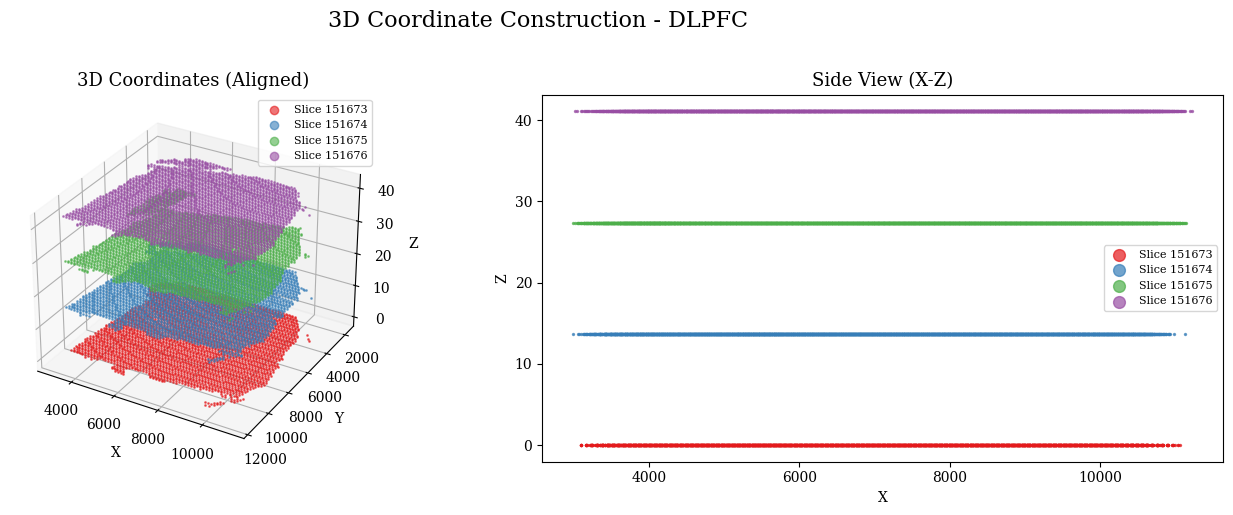

Saved: 3d_coordinate_visualization.pdf


In [5]:
# ---- 3D visualization ----
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
for i, a in enumerate(aligned_list):
    xy = a.obsm['spatial_aligned']
    ax1.scatter(xy[:, 0], xy[:, 1], zs=all_z[i][0], c=COLORS[i], s=1, alpha=0.6,
                label='Slice %d' % SLICE_IDS[i], depthshade=False)
ax1.set_title('3D Coordinates (Aligned)', fontsize=13)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend(markerscale=6, fontsize=8); ax1.invert_yaxis()

ax2 = fig.add_subplot(1, 2, 2)
for i, a in enumerate(aligned_list):
    xy = a.obsm['spatial_aligned']
    ax2.scatter(xy[:, 0], np.full(xy.shape[0], all_z[i][0]),
                c=COLORS[i], s=2, alpha=0.7, label='Slice %d' % SLICE_IDS[i])
ax2.set_title('Side View (X-Z)', fontsize=13)
ax2.set_xlabel('X'); ax2.set_ylabel('Z')
ax2.legend(markerscale=6, fontsize=8)

plt.suptitle('3D Coordinate Construction - DLPFC', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '3d_coordinate_visualization.pdf'), bbox_inches='tight')
plt.show()
print('Saved: 3d_coordinate_visualization.pdf')

## 4. Construct 3D Coordinates

3D coordinates = aligned 2D xy + slice depth z.

In [6]:
# ---- Merge ----
print('Merging slices (inner join on genes)...')
adata_merged = aligned_list[0].concatenate(
    aligned_list[1:], batch_key='slice_batch', join='inner', index_unique=None)
adata_merged.obsm['3D_coor'] = coords_3d
adata_merged.obsm['spatial'] = np.vstack(all_xy)
print('  Merged: %d spots x %d genes' % (adata_merged.shape[0], adata_merged.shape[1]))

# ---- Preprocess ----
print('Filter genes (min_cells=3)...')
sc.pp.filter_genes(adata_merged, min_cells=3)

print('Normalize total + log1p...')
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)

# Save per-slice raw
for i in range(len(aligned_list)):
    mask = adata_merged.obs['slice_batch'].astype(str) == str(i)
    a_slice = adata_merged[mask].copy()
    fname = 'adata_st_list_raw%d.h5ad' % i
    a_slice.write(fname)
    print('  Saved: %s (%d spots)' % (fname, a_slice.shape[0]))

# HVG + scale
print('\nSelect top %d HVGs...' % N_HVG)
sc.pp.highly_variable_genes(adata_merged, n_top_genes=N_HVG)
adata_hvg = adata_merged[:, adata_merged.var['highly_variable']].copy()

print('Z-score scale (max_value=10)...')
sc.pp.scale(adata_hvg, max_value=10)
adata_hvg.obsm['3D_coor'] = coords_3d
adata_hvg.obsm['spatial'] = np.vstack(all_xy)

adata_hvg.write('adata_st_DLPFC.h5ad')
print('  Saved: adata_st_DLPFC.h5ad (%d x %d)' % adata_hvg.shape)

Merging slices (inner join on genes)...


  Merged: 14364 spots x 33538 genes
Filter genes (min_cells=3)...


Normalize total + log1p...


... storing 'feature_types' as categorical


... storing 'genome' as categorical


...

  Saved: adata_st_list_raw3.h5ad (3460 spots)

Select top 3000 HVGs...


Z-score scale (max_value=10)...


... storing 'feature_types' as categorical


... storing 'genome' as categorical


  Saved: adata_st_DLPFC.h5ad (14364 x 3000)


---

## 5. Coordinate Normalization Preview

AINR's SIREN network expects input in [-1, 1]. `Model.__init__` handles this:
coord_norm = 2 * (coord - min) / (max - min + eps) - 1

In [ ]:
## 5. Merge & Preprocess

Merge 4 slices, filter, normalize, log1p, HVG selection, scale.

# ---- Merge ----
print('Merging slices (inner join on genes)...')
adata_merged = aligned_list[0].concatenate(
    aligned_list[1:], batch_key='slice_batch', join='inner', index_unique=None)
adata_merged.obsm['3D_coor'] = coords_3d
adata_merged.obsm['spatial'] = np.vstack(all_xy)
print('  Merged: %d spots x %d genes' % (adata_merged.shape[0], adata_merged.shape[1]))

# ---- Preprocess ----
print('Filter genes (min_cells=3)...')
sc.pp.filter_genes(adata_merged, min_cells=3)

print('Normalize total + log1p...')
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)

# Save per-slice raw to project root (Model class expects them there)
for i in range(len(aligned_list)):
    mask = adata_merged.obs['slice_batch'].astype(str) == str(i)
    a_slice = adata_merged[mask].copy()
    fname = '../adata_st_list_raw%d.h5ad' % i
    a_slice.write(fname)
    print('  Saved: %s (%d spots)' % (fname, a_slice.shape[0]))

# HVG + scale
print('\nSelect top %d HVGs...' % N_HVG)
sc.pp.highly_variable_genes(adata_merged, n_top_genes=N_HVG)
adata_hvg = adata_merged[:, adata_merged.var['highly_variable']].copy()

print('Z-score scale (max_value=10)...')
sc.pp.scale(adata_hvg, max_value=10)
adata_hvg.obsm['3D_coor'] = coords_3d
adata_hvg.obsm['spatial'] = np.vstack(all_xy)

adata_hvg.write('../adata_st_DLPFC.h5ad')
print('  Saved: ../adata_st_DLPFC.h5ad (%d x %d)' % adata_hvg.shape)